In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

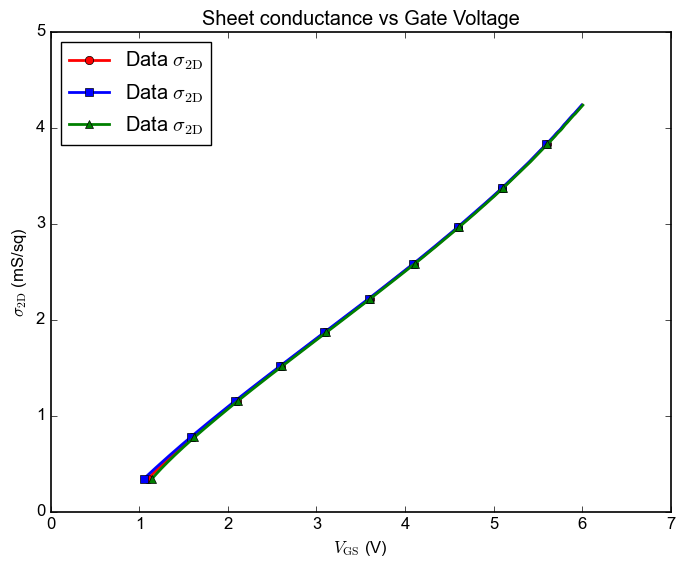

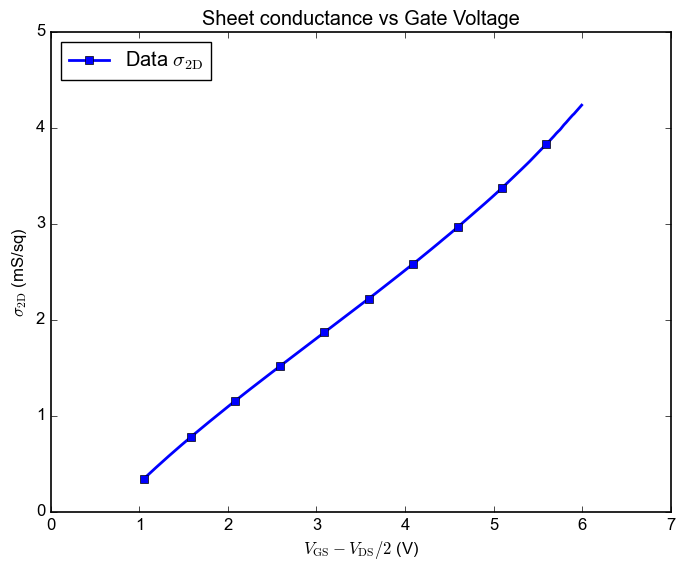

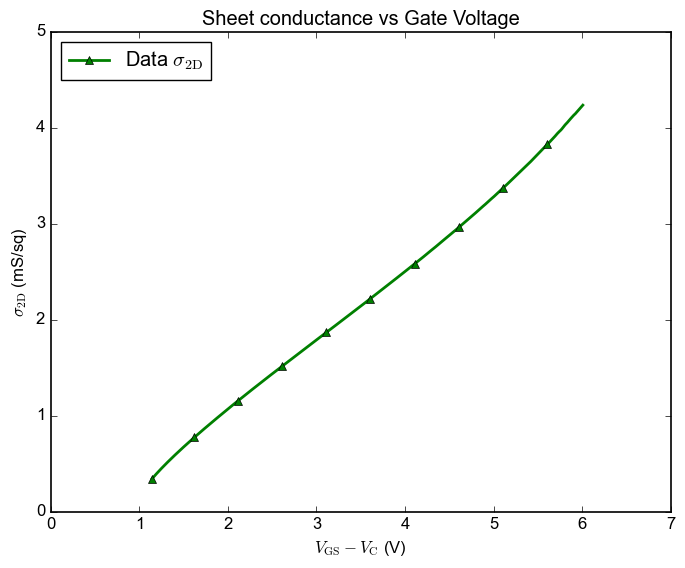

In [38]:
data = np.loadtxt("./Mobility/20262004004.dat")
V_GS = data[:, 0]
I_DS = data[:, 2]
V_DS = data[:, 3]
V_C = 0.5*(data[:, 4] + data[:, 5])
V_12 = data[:, 6]
sigma = data[:, 7]

plt.plot(V_GS, sigma*1e3, lw=2, label=r'Data $\sigma_\text{2D}$', color='red', marker='o', linestyle='-', markevery=40)
plt.plot(V_GS - 0.5*V_DS, sigma*1e3, lw=2, label=r'Data $\sigma_\text{2D}$', color='blue', marker='s', linestyle='-', markevery=40)
plt.plot(V_GS - V_C, sigma*1e3, lw=2, label=r'Data $\sigma_\text{2D}$', color='green', marker='^', linestyle='-', markevery=40)
plt.xlabel(r"$V_\text{GS}$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ (mS/sq)")
plt.xlim(0, 7)
plt.ylim(0, 5)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()

plt.plot(V_GS - 0.5*V_DS, sigma*1e3, lw=2, label=r'Data $\sigma_\text{2D}$', color='blue', marker='s', linestyle='-', markevery=40)
plt.xlabel(r"$V_\text{GS} - V_\text{DS}/2$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ (mS/sq)")
plt.xlim(0, 7)
plt.ylim(0, 5)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()

plt.plot(V_GS - V_C, sigma*1e3, lw=2, label=r'Data $\sigma_\text{2D}$', color='green', marker='^', linestyle='-', markevery=40)
plt.xlabel(r"$V_\text{GS} - V_\text{C}$ (V)")
plt.ylabel(r"$\sigma_\text{2D}$ (mS/sq)")
plt.xlim(0, 7)
plt.ylim(0, 5)
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Sheet conductance vs Gate Voltage")
plt.show()

a = 0.00076 ± 1.61e-06
b = -0.00049 ± 6.18e-06
R^2 = 1 - 0.002
V_T = (0.644 ± 0.00824) V
mu_int = (1.27e+03 ± 2.69) cm^2/Vs


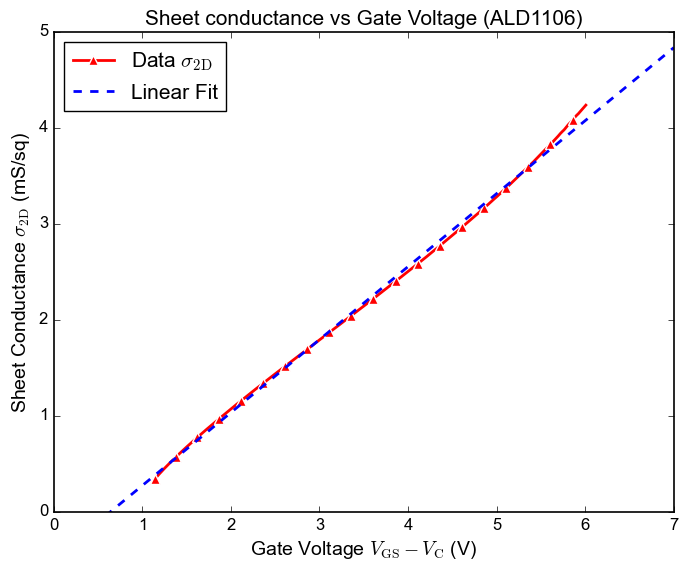

In [ ]:
C = 3e-12 # 3pF
W = 50e-6 # 50um
L = 10e-6 # 10um
Ci = C / (W * L) # F/m^2
V_del = (V_GS - V_C)

def func(x, a, b):
    return a * x + b

popt, pcov = curve_fit(func, V_del, sigma)
sigma_fit = func(V_del, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((sigma - sigma_fit) ** 2)
ss_tot = np.sum((sigma - np.mean(sigma)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr
V_T_fit = -b / a
V_T_err = abs(V_T_fit) * np.sqrt((b_err / b) ** 2 + (a_err / a) ** 2)
mu_fit = a / Ci * 1e4
mu_err = abs(mu_fit * a_err / a)

print(f"a = {a:.3g} ± {a_err:.3g}")
print(f"b = {b:.3g} ± {b_err:.3g}")
print(f"R^2 = 1 - {1-r2:.1g}")

print(f"V_T = ({V_T_fit:.3g} ± {V_T_err:.3g}) V")
print(f"mu_int = ({mu_fit:.3g} ± {mu_err:.3g}) cm^2/Vs")



x = np.linspace(0, 7, 100)
plt.plot(V_GS - V_C, sigma*1e3, '^', label=r'Data $\sigma_\text{2D}$',lw=2,ls='-', color='red', markevery=20, markeredgecolor="white", markeredgewidth=1, markersize=7)
plt.plot(x, func(x, *popt)*1e3, lw=2, label='Linear Fit', color='blue', linestyle='--')
plt.xlabel(r"Gate Voltage $V_\text{GS} - V_\text{C}$ (V)", fontsize=14)
plt.ylabel(r"Sheet Conductance $\sigma_\text{2D}$ (mS/sq)", fontsize=14)
plt.xlim(0, 7)
plt.ylim(0, 5)
plt.legend(frameon=True, loc='upper left', numpoints=1, fontsize=15)
plt.title(r"Sheet conductance vs Gate Voltage (ALD1106)", fontsize=15)
# plt.savefig("conductance_fit.eps", format='eps', bbox_inches='tight')
plt.show()

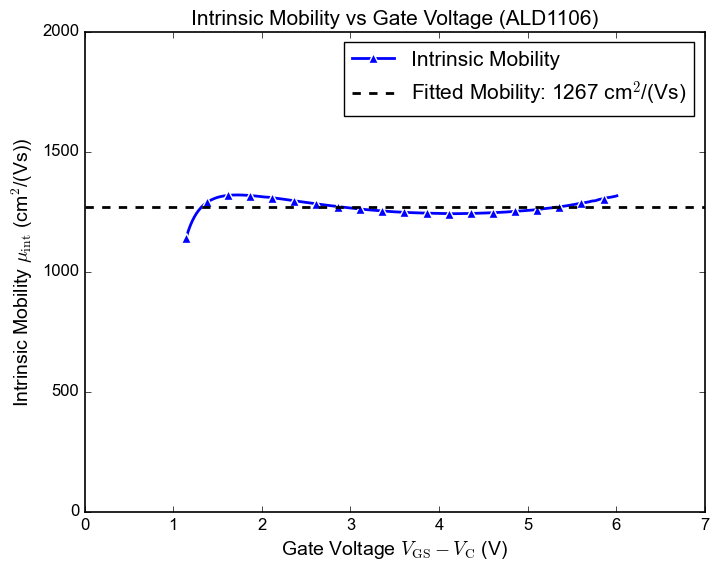

In [ ]:
mu_int = sigma / (Ci * (V_GS - V_C - V_T_fit)) * 1e4

plt.plot(V_GS - V_C, mu_int, '^', label=r'Intrinsic Mobility', color='blue',lw=2, ls='-', markevery=20, markeredgecolor="white", markeredgewidth=1, markersize=7)
plt.plot(x, np.full_like(x, mu_fit), lw=2, label=rf'Fitted Mobility: {mu_fit:.0f} cm$^2$/(Vs)', color='k', linestyle='--')
plt.xlabel(r"Gate Voltage $V_\text{GS} - V_\text{C}$ (V)", fontsize=14)
plt.ylabel(r"Intrinsic Mobility $\mu_\text{int}$ (cm$^2$/(Vs))", fontsize=14)
plt.xlim(0, 7)
plt.ylim(0, 2000)
plt.legend(frameon=True, loc='upper right', numpoints=1, fontsize=15)
plt.title(r"Intrinsic Mobility vs Gate Voltage (ALD1106)", fontsize=15)
# plt.savefig("mobility_fit.eps", format='eps', bbox_inches='tight')
plt.show()